## Introduction

This project seeks to identify savings-related behavioral patterns using World Bank Group data from global surveys conducted in 2011, 2014, 2017, 2021, 2022, and 2024.

The study focuses primarily on analyzing the behaviors of young people to help develop resources that foster their saving capacity.

Main question for the analysis:

**What characteristics distinguish young people who save from those who do not, and what hypotheses could help interpret these differences?**

## Preparation

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
# Select path

path = r"C:\Users\Pablo\Documents\Data_projects\2609_world_bank_group\GlobalFindexDatabase2025.csv"

In [3]:
# Download Dataset

df_raw = pd.read_csv(path)

C:\Users\Pablo\AppData\Local\Temp\ipykernel_2940\823745170.py:3: DtypeWarning: Columns (0: regionwb24_hi, 1: incomegroupwb24) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(path)


In [4]:
# Show dataframe shape

print(f"Loaded Dataset: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")

Loaded Dataset: 8577 rows, 438 columns


In [5]:
# Show dataframe information

print(df_raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 8577 entries, 0 to 8576
Columns: 438 entries, countrynewwb to con32h_s
dtypes: float64(431), int64(1), str(6)
memory usage: 29.3 MB
None


In [6]:
# Show dataframe

print(df_raw)

             countrynewwb codewb  year   pop_adult  \
0             Afghanistan    AFG  2011  14575546.0   
1                 Albania    ALB  2011   2281010.0   
2                 Algeria    DZA  2011  26251587.0   
3                  Angola    AGO  2011  12779501.0   
4               Argentina    ARG  2011  30685516.0   
...                   ...    ...   ...         ...   
8572           Low income    LIC  2024         NaN   
8573  Lower middle income    LMC  2024         NaN   
8574  Lower middle income    LMC  2024         NaN   
8575  Upper middle income    UMC  2024         NaN   
8576  Upper middle income    UMC  2024         NaN   

                                          regionwb24_hi      incomegroupwb24  \
0                    South Asia (excluding high income)           Low income   
1         Europe & Central Asia (excluding high income)  Upper middle income   
2     Middle East & North Africa (excluding high inc...  Lower middle income   
3            Sub-Saharan Africa

In [7]:
# Show first rows of dataframe

print(df_raw.head())

  countrynewwb codewb  year   pop_adult  \
0  Afghanistan    AFG  2011  14575546.0   
1      Albania    ALB  2011   2281010.0   
2      Algeria    DZA  2011  26251587.0   
3       Angola    AGO  2011  12779501.0   
4    Argentina    ARG  2011  30685516.0   

                                       regionwb24_hi      incomegroupwb24  \
0                 South Asia (excluding high income)           Low income   
1      Europe & Central Asia (excluding high income)  Upper middle income   
2  Middle East & North Africa (excluding high inc...  Lower middle income   
3         Sub-Saharan Africa (excluding high income)  Lower middle income   
4  Latin America & Caribbean (excluding high income)  Upper middle income   

  group group2  account_t_d  fiaccount_t_d  ...  con12m_s  con26lm_s  \
0   all    all     0.090050       0.090050  ...       NaN        NaN   
1   all    all     0.282681       0.282681  ...       NaN        NaN   
2   all    all     0.332861       0.332861  ...       NaN     

- Note: There can be seen some missing values.

## Data cleaning

In [8]:
# ========================
# Cleaning headers
# ========================

print(df_raw.columns.tolist())


['countrynewwb', 'codewb', 'year', 'pop_adult', 'regionwb24_hi', 'incomegroupwb24', 'group', 'group2', 'account_t_d', 'fiaccount_t_d', 'mobileaccount_t_d', 'borrow_any_t_d', 'fin4_d', 'dig_acc', 'fin11_2a', 'fin11a', 'fin11b', 'fin11c', 'fin11f', 'fin11d', 'fin11e', 'fin14a', 'fin14b', 'fin14c', 'fin14d', 'fin13_1a', 'fin13_1b', 'fin26a', 'fin26b', 'fin27a', 'fin27b', 'fin17f', 'fin17a_17a1_d', 'fin17a', 'fin17b', 'fin17c', 'fin22d', 'fin22e', 'fin22a_22a1_22g_d', 'fin22a', 'fin22a_22g', 'fin22a_1', 'fin22b', 'fin22c', 'fin24sav', 'fin24fam', 'fin24work', 'fin24bor', 'fin24sell', 'fin24other', 'fin24aVD', 'fin24aSD', 'fin24aND', 'fin24aSD_ND', 'fin24aP', 'fin24aN', 'fin24sav_SD_ND', 'fin24fam_SD_ND', 'fin24work_SD_ND', 'fin24bor_SD_ND', 'fin24sell_SD_ND', 'fin24other_SD_ND', 'fin24sav_VD', 'fin24fam_VD', 'fin24work_VD', 'fin24bor_VD', 'fin24sell_VD', 'fin24other_VD', 'fh1', 'fin28', 'fh2', 'fin29', 'fin31a_31b', 'fin30', 'fin31a', 'fin31b', 'fin31d', 'fin32_33_34a', 'fin32_33_34b', 'fi

- Note: Headers have the right format

In [9]:
# =====================================
# Categorial typos
# =====================================

# Look for duplicates in the categorical columns

print(df_raw['countrynewwb'].value_counts())
print(df_raw['codewb'].value_counts())
print(df_raw['regionwb24_hi'].value_counts())
print(df_raw['incomegroupwb24'].value_counts())
print(df_raw['group'].value_counts())
print(df_raw['group2'].value_counts())

countrynewwb
Albania        57
Algeria        57
Argentina      57
Armenia        57
Australia      57
               ..
Bhutan         11
Puerto Rico    11
Somalia        11
Maldives       11
Djibouti        9
Name: count, Length: 174, dtype: int64
codewb
ALB    57
DZA    57
ARG    57
ARM    57
AUS    57
       ..
BTN    11
PRI    11
SOM    11
MDV    11
DJI     9
Name: count, Length: 174, dtype: int64
regionwb24_hi
High income                                           2643
Sub-Saharan Africa (excluding high income)            1883
Europe & Central Asia (excluding high income)         1038
Latin America & Caribbean (excluding high income)      930
Middle East & North Africa (excluding high income)     537
East Asia & Pacific (excluding high income)            521
South Asia (excluding high income)                     341
Name: count, dtype: int64
incomegroupwb24
High income            2643
Lower middle income    2211
Upper middle income    2089
Low income              950
Name: count, 

- Note: There are some duplicates. Deeper exploration is needed.

In [10]:
# Explore data per year

print(df_raw['year'].value_counts().sort_index(ascending=False))

year
2024    1982
2022     176
2021    1483
2017    1734
2014    1686
2011    1516
Name: count, dtype: int64


- How much missing values are in the dataset?

In [11]:
# Search for missing values

count_nulls= df_raw.isnull().sum()

print(count_nulls)

countrynewwb        0
codewb              0
year                0
pop_adult         684
regionwb24_hi     684
                 ... 
con26m_s         8576
con28lm_s        8576
con5a_s          8576
con17c_s         8576
con32h_s         8576
Length: 438, dtype: int64


In [12]:
# Columns % missing values

null_percentage = df_raw.isna().mean()*100

print(null_percentage.sort_values(ascending=False))

con32h_s          99.988341
con13_s           99.988341
fin37_38_39d_s    99.988341
fin32_33_34b_s    99.988341
con12m_s          99.988341
                    ...    
codewb             0.000000
group2             0.000000
group              0.000000
year               0.000000
countrynewwb       0.000000
Length: 438, dtype: float64


## Savings in LATAM

In [13]:
# Columns related to savings

# cols_save = ['save_any_t_d', 'fin17a', 'fin17a_17a1_d', 'fin17b', 'fin17c', 'fin17f', 'fin17dw', 'fin17dm', 'fin17dlm', 'fin17e', 'fin22c', 'fin24sav', 'fin24ba', 'fin24bb', 'fin24bc', 'fin24bd']

- Segment the dataframe

In [14]:
# Filter LATAM countries & year

lam_countries =df_raw[df_raw['regionwb24_hi'] == 'Latin America & Caribbean (excluding high income)']

lam_countries_2024 = lam_countries[lam_countries['year'] == 2024]

print(lam_countries_2024)

       countrynewwb codewb  year    pop_adult  \
573       Argentina    ARG  2024   35433130.0   
581          Belize    BLZ  2024     300138.0   
583         Bolivia    BOL  2024    8553476.0   
586          Brazil    BRA  2024  169047814.0   
595        Colombia    COL  2024   41544122.0   
...             ...    ...   ...          ...   
7816       Paraguay    PRY  2024    4874331.0   
7817           Peru    PER  2024   25601447.0   
7818           Peru    PER  2024   25601447.0   
7883  Venezuela, RB    VEN  2024   20899114.0   
7884  Venezuela, RB    VEN  2024   20899114.0   

                                          regionwb24_hi      incomegroupwb24  \
573   Latin America & Caribbean (excluding high income)  Upper middle income   
581   Latin America & Caribbean (excluding high income)  Upper middle income   
583   Latin America & Caribbean (excluding high income)  Lower middle income   
586   Latin America & Caribbean (excluding high income)  Upper middle income   
595   Latin

In [15]:
# Isolate young people by group 2 category

young_lam_2024 = lam_countries_2024[lam_countries_2024['group2'] == 'ages 15-24']

print(young_lam_2024)

            countrynewwb codewb  year    pop_adult  \
4579           Argentina    ARG  2024   35433130.0   
4595              Belize    BLZ  2024     300138.0   
4599             Bolivia    BOL  2024    8553476.0   
4605              Brazil    BRA  2024  169047814.0   
4623            Colombia    COL  2024   41544122.0   
4631          Costa Rica    CRI  2024    4118576.0   
4643  Dominican Republic    DOM  2024    8281568.0   
4645             Ecuador    ECU  2024   13484219.0   
4649         El Salvador    SLV  2024    4718943.0   
4673           Guatemala    GTM  2024   12299923.0   
4677            Honduras    HND  2024    7345357.0   
4743              Mexico    MEX  2024   97411242.0   
4763           Nicaragua    NIC  2024    4830854.0   
4779            Paraguay    PRY  2024    4874331.0   
4781                Peru    PER  2024   25601447.0   
4847       Venezuela, RB    VEN  2024   20899114.0   

                                          regionwb24_hi      incomegroupwb24  \
4

In [16]:
print(young_lam_2024.info())

<class 'pandas.DataFrame'>
Index: 16 entries, 4579 to 4847
Columns: 438 entries, countrynewwb to con32h_s
dtypes: float64(431), int64(1), str(6)
memory usage: 56.4 KB
None


In [17]:
# Keep columns that have at least % threshold

threshold = 0.6
young_lam_2024 = young_lam_2024.dropna(axis=1, thresh=len(young_lam_2024) * threshold)

In [18]:
# Check how many columns are left

print(young_lam_2024.info())
print()
print(young_lam_2024)
print()

<class 'pandas.DataFrame'>
Index: 16 entries, 4579 to 4847
Columns: 116 entries, countrynewwb to con30h
dtypes: float64(109), int64(1), str(6)
memory usage: 16.1 KB
None

            countrynewwb codewb  year    pop_adult  \
4579           Argentina    ARG  2024   35433130.0   
4595              Belize    BLZ  2024     300138.0   
4599             Bolivia    BOL  2024    8553476.0   
4605              Brazil    BRA  2024  169047814.0   
4623            Colombia    COL  2024   41544122.0   
4631          Costa Rica    CRI  2024    4118576.0   
4643  Dominican Republic    DOM  2024    8281568.0   
4645             Ecuador    ECU  2024   13484219.0   
4649         El Salvador    SLV  2024    4718943.0   
4673           Guatemala    GTM  2024   12299923.0   
4677            Honduras    HND  2024    7345357.0   
4743              Mexico    MEX  2024   97411242.0   
4763           Nicaragua    NIC  2024    4830854.0   
4779            Paraguay    PRY  2024    4874331.0   
4781               

In [19]:
# LATAM countries per savings

savings_country = young_lam_2024.groupby('countrynewwb')['save_any_t_d'].mean().sort_values(ascending=False)
print(savings_country)

countrynewwb
Argentina             0.715191
Belize                0.706127
Venezuela, RB         0.684634
Costa Rica            0.657966
Brazil                0.645537
Dominican Republic    0.630467
Mexico                0.599814
Bolivia               0.588771
Honduras              0.548103
Peru                  0.528982
Ecuador               0.514147
Paraguay              0.493279
El Salvador           0.493178
Guatemala             0.486332
Nicaragua             0.481724
Colombia              0.379754
Name: save_any_t_d, dtype: float64


C:\Users\Pablo\AppData\Local\Temp\ipykernel_2940\4139254864.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


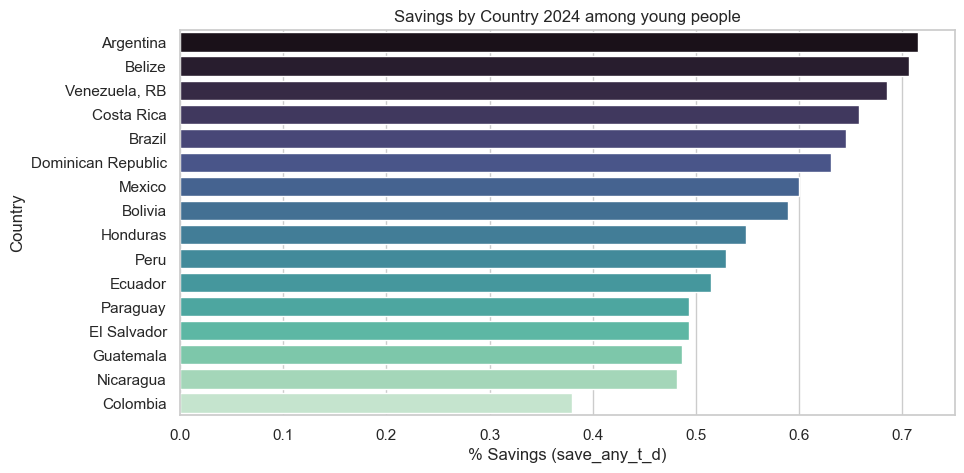

In [20]:
# Graph

df_plot = young_lam_2024.set_index('countrynewwb').sort_values(by='save_any_t_d',ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(
    data=df_plot,
    x="save_any_t_d",
    y="countrynewwb",
    palette='mako'
)

plt.title('Savings by Country 2024 among young people')
plt.ylabel("Country")
plt.xlabel('% Savings (save_any_t_d)')
plt.savefig('comparison_2024_savings_country.png', dpi=150)
plt.show()

Rank of young people saving per country

In [21]:
# List datframe's columns

print(young_lam_2024.columns.to_list())

['countrynewwb', 'codewb', 'year', 'pop_adult', 'regionwb24_hi', 'incomegroupwb24', 'group', 'group2', 'account_t_d', 'fiaccount_t_d', 'mobileaccount_t_d', 'borrow_any_t_d', 'fin4_d', 'dig_acc', 'fin11_2a', 'fin11a', 'fin11b', 'fin11c', 'fin11f', 'fin11d', 'fin11e', 'fin26a', 'fin26b', 'fin27a', 'fin17a_17a1_d', 'fin17a', 'fin22d', 'fin22a_22a1_22g_d', 'fin22a_22g', 'fin22b', 'fin24sav', 'fin24fam', 'fin24work', 'fin24aVD', 'fin24aSD', 'fin24aND', 'fin24aSD_ND', 'fin24aP', 'fin24sav_SD_ND', 'fin24fam_SD_ND', 'fin24fam_VD', 'fh1', 'fin28', 'fh2', 'fin29', 'fin31a_31b', 'fin30', 'fin31a', 'fin31b', 'fin31d', 'fin32_n33_34a', 'fin32_n33_acc', 'fin32_n33', 'fin32', 'fin32_acc', 'fin34a', 'fin37_38', 'fin2_t_d', 'fin45a', 'fin45c', 'fin45d', 'fin25e2', 'fin9b', 'fin10', 'fing2p', 'g20_made', 'g20_received', 'g20_any', 'merchant_pay', 'save_any_t_d', 'fin5m', 'fin6w', 'fin6m', 'fin6lm', 'fin9a', 'fin17dm', 'fin3', 'fin24ba', 'fin24bb', 'fin24bc', 'fin24bd', 'fin24c', 'fin24d1', 'fin25e1', 'f

In [22]:
# Isolate numeric features

numeric = young_lam_2024.columns.tolist()
exclude = ['countrynewwb', 'codewb', 'year', 'pop_adult', 'regionwb24_hi', 'incomegroupwb24', 'group', 'group2']
numeric = [x for x in numeric if x not in exclude]
print(numeric)

['account_t_d', 'fiaccount_t_d', 'mobileaccount_t_d', 'borrow_any_t_d', 'fin4_d', 'dig_acc', 'fin11_2a', 'fin11a', 'fin11b', 'fin11c', 'fin11f', 'fin11d', 'fin11e', 'fin26a', 'fin26b', 'fin27a', 'fin17a_17a1_d', 'fin17a', 'fin22d', 'fin22a_22a1_22g_d', 'fin22a_22g', 'fin22b', 'fin24sav', 'fin24fam', 'fin24work', 'fin24aVD', 'fin24aSD', 'fin24aND', 'fin24aSD_ND', 'fin24aP', 'fin24sav_SD_ND', 'fin24fam_SD_ND', 'fin24fam_VD', 'fh1', 'fin28', 'fh2', 'fin29', 'fin31a_31b', 'fin30', 'fin31a', 'fin31b', 'fin31d', 'fin32_n33_34a', 'fin32_n33_acc', 'fin32_n33', 'fin32', 'fin32_acc', 'fin34a', 'fin37_38', 'fin2_t_d', 'fin45a', 'fin45c', 'fin45d', 'fin25e2', 'fin9b', 'fin10', 'fing2p', 'g20_made', 'g20_received', 'g20_any', 'merchant_pay', 'save_any_t_d', 'fin5m', 'fin6w', 'fin6m', 'fin6lm', 'fin9a', 'fin17dm', 'fin3', 'fin24ba', 'fin24bb', 'fin24bc', 'fin24bd', 'fin24c', 'fin24d1', 'fin25e1', 'fin25e2b', 'fin25e4d', 'fh2a', 'fin36b', 'fin8', 'fin22f', 'fh1_fh2', 'fin28_29', 'con1', 'con9a', 'con

In [23]:
# Eliminate variables related with digital behaviour

numeric_not_con = [v for v in numeric if not v.startswith('con')]
print(f'Original variables: {len(numeric)}')

print(f'Variables related with financial behaviour: {len(numeric_not_con)}')

Original variables: 108
Variables related with financial behaviour: 85


In [24]:
# Which features are most correlated with savings

corr = young_lam_2024[numeric_not_con].corr()

features_corr = corr['save_any_t_d'].drop('save_any_t_d').sort_values(key=abs, ascending=False)
print(features_corr.to_string())

fing2p               0.719014
fin8                 0.700007
fin37_38             0.687997
fiaccount_t_d        0.676467
fin2_t_d             0.673696
fin22b               0.661777
fin24d1              0.659099
fin4_d               0.658572
borrow_any_t_d       0.647190
fin24sav_SD_ND      -0.615922
fin6w                0.615852
fin11b              -0.611816
fin17a               0.605098
g20_received         0.602200
fin3                 0.591037
account_t_d          0.587574
fin24aP              0.569468
g20_any              0.567439
fin9b                0.528634
fin32                0.524646
fin31d              -0.515786
fin9a                0.514106
fin17a_17a1_d        0.510440
dig_acc              0.474607
fin36b               0.464019
fin25e1              0.460355
g20_made             0.459536
fin25e2              0.457692
fh1_fh2              0.448369
fin34a               0.435738
merchant_pay         0.435665
fh2                  0.428917
fin24sav            -0.426735
fin32_acc 

In [25]:
# Select the most important correlations to analyze

top_vars = features_corr[features_corr.abs() > 0.6].index.tolist()
corr_block = young_lam_2024[top_vars].corr()

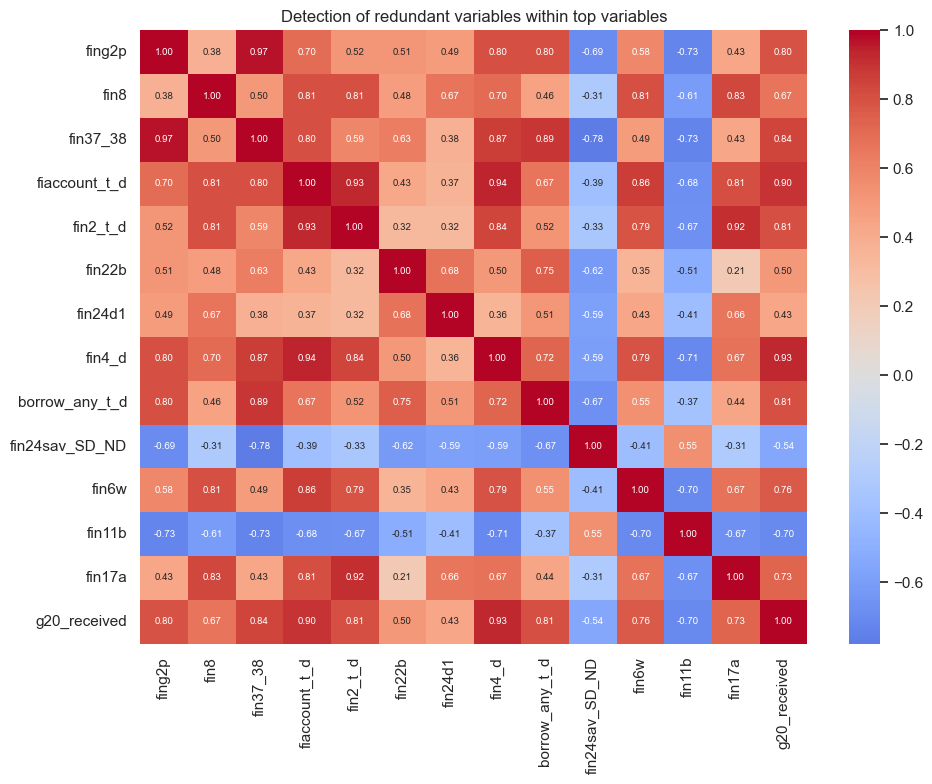

In [26]:
# Look for redundant variables

plt.figure(figsize=(10,8))
sns.heatmap(corr_block, cmap='coolwarm', center=0, annot=True, fmt='.2f', annot_kws={'size':7})
plt.title('Detection of redundant variables within top variables')
plt.tight_layout()
plt.show()

## Savings in a sample of 5 LATAM countries

In [27]:
# Countries to compare young people 

countries = ['Argentina', 'Brazil', 'Mexico','Peru', 'Colombia']

# Top correlated variables

clean_var = ['fing2p', 'fiaccount_t_d', 'fin22b', 'borrow_any_t_d', 'fin6w', 'g20_received', 'fin3', 'fin24aP', 'g20_any', 'fin9b']

In [28]:
# Which features are most correlated with savings without redundant variables

corr_block = young_lam_2024[clean_var].corr()

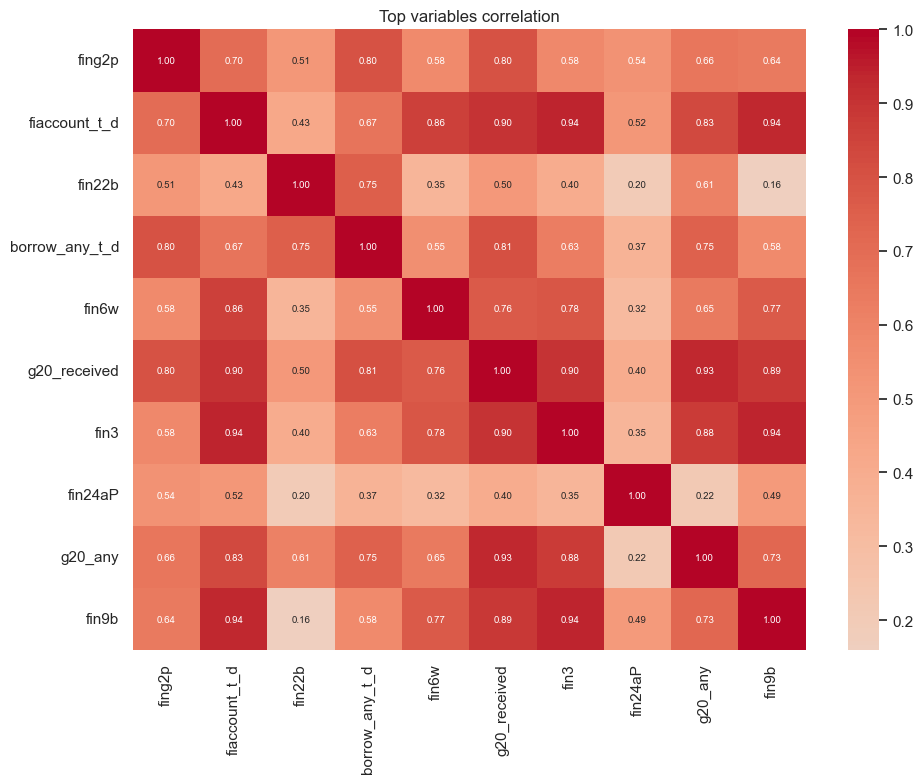

In [29]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_block, cmap='coolwarm', center=0, annot=True, fmt='.2f', annot_kws={'size':7})
plt.title('Top variables correlation')
plt.tight_layout()
plt.show()

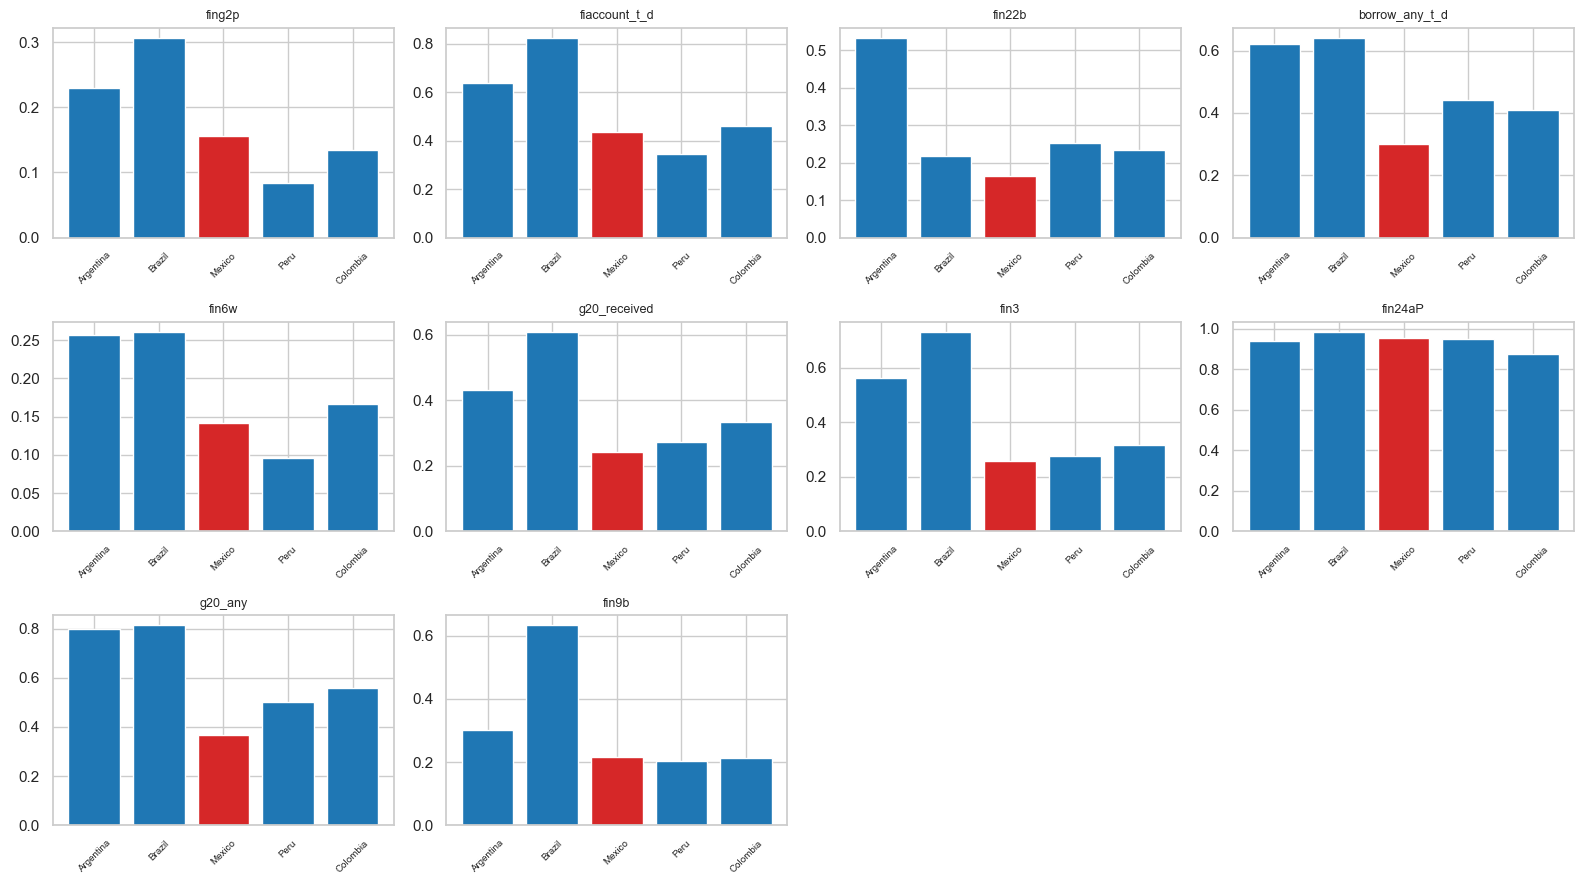

In [30]:
# Graph top correlated variables with savings by country to look for trends

df_5countries = young_lam_2024[young_lam_2024['countrynewwb'].isin(countries)].set_index('countrynewwb')

n_cols = 4
n_rows = int(np.ceil(len(clean_var) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()

for i, var in enumerate(clean_var):
    values = df_5countries[var].reindex(countries)
    colors = ['#d62728' if p == 'Mexico' else '#1f77b4' for p in countries]  # Focus on
    axes[i].bar(countries, values, color=colors)
    axes[i].set_title(var, fontsize=9)
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('comparison_5countries.png', dpi=150)
plt.show()

At the regional level, the variables most strongly correlated with saving among young people in Latin America are: 
1) receiving government payments, 
2) having an account, 
3) having borrowed money from family and friends, 
4) having borrowed money, 
5) sending or withdrawing money via a bank, 
6) receiving digital payments, 
7) using a phone or card to make digital payments, 
8) having an emergency fund 
9) made a digital payment, and 
10) using a phone to check one's balance.

However, there is no clear relationship between the countries where young people save the most and the variables most strongly correlated with saving. 

Overall, it can be stated that the characteristics associated with saving are linked to financial inclusion (1,2,5,6,7,9,10) and an informal lending network (3,4).

## Savings in Mexico

In [31]:
# Filter data from Mexico and year

df_mx = df_raw[df_raw['countrynewwb'] == 'Mexico']
df_mx_2024 = df_mx[df_mx['year'] == 2024]

In [32]:
# Savings per group

savings_mx_group2 = df_mx_2024.groupby('group2')['save_any_t_d'].mean().sort_values(ascending=False)
print(savings_mx_group2)

group2
ages 15-24               0.599814
in laborforce            0.595950
secondary edu or more    0.569274
richest 60%              0.556135
men                      0.549910
urban                    0.541064
all                      0.483414
age 25+                  0.450004
women                    0.422105
rural                    0.402300
poorest 40%              0.374177
out of laborforce        0.293109
prim edu or less         0.282004
Name: save_any_t_d, dtype: float64


C:\Users\Pablo\AppData\Local\Temp\ipykernel_2940\4169706069.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


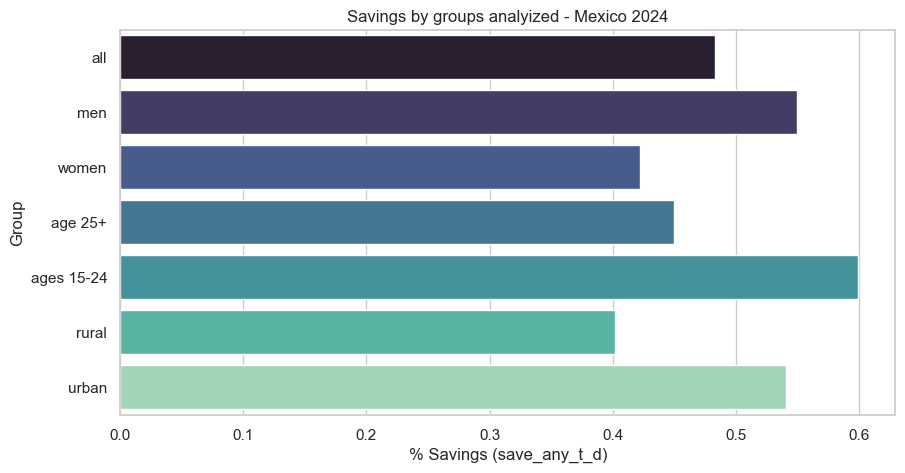

In [33]:
# Graph
analyzed_groups = ['all', 'men', 'women', 'age 25+', 'ages 15-24', 'rural', 'urban']
df_plot = df_mx_2024[df_mx_2024['group2'].isin(analyzed_groups)].set_index('group2')

plt.figure(figsize=(10,5))

sns.barplot(
    data=df_plot,
    x="save_any_t_d",
    y="group2",
    palette='mako'
)

plt.title('Savings by groups analyized - Mexico 2024')
plt.ylabel("Group")
plt.xlabel('% Savings (save_any_t_d)')
plt.savefig('comparison_2024_savings_mx_group.png', dpi=150)
plt.show()

The group of ages 15-24 (young people) is the group that save more. Men save more then woman and urban people save more than rural people.

In [34]:
# Which are the main differences between ages groups in Mexico

mx_2024 = df_raw[(df_raw['countrynewwb'] == 'Mexico') & (df_raw['year'] == 2024)]
mx_age = df_mx_2024[df_mx_2024['group2'].isin(['ages 15-24', 'age 25+'])].set_index('group2')

diffs_abs = mx_age[numeric_not_con].loc['ages 15-24'] - mx_age[numeric_not_con].loc['age 25+']
diffs_abs = diffs_abs.dropna().sort_values(key=abs, ascending=False)
print(diffs_abs.to_string())

fin30               -0.248619
fin11e               0.231437
fin31d              -0.216612
internet             0.199244
save_any_t_d         0.149809
borrow_any_t_d      -0.146614
fiaccount_t_d       -0.115951
fin2_t_d            -0.113149
fin45a              -0.113051
fin24bb              0.109113
account_t_d         -0.107619
fin11f               0.089020
fin22a_22a1_22g_d   -0.087705
fin22f              -0.084790
fin22a_22g          -0.083795
fin24bd             -0.081153
fin9a               -0.078111
fin32_n33            0.078086
fin6w               -0.075380
fing2p              -0.074825
fin45c              -0.073517
fin25e2b            -0.073024
fin5m               -0.072351
fin3                -0.070297
fin26b               0.069229
fin24fam             0.068814
fin25e4d            -0.068512
fin10               -0.068177
fin24aSD             0.067817
g20_received        -0.067808
fin24sav             0.063939
fin32                0.063918
fin37_38            -0.063529
fin26a    

In [35]:
diff_relative = (mx_age[numeric_not_con].loc['ages 15-24'] / mx_age[numeric_not_con].loc['age 25+'] - 1) * 100
diff_relative = diff_relative.replace([float('inf'), -float('inf')], None).dropna().sort_values(key=abs, ascending=False)
print(diff_relative.to_string())

fin11e               193.472633
fin11f                69.461105
fin45a               -60.815049
fin22a_22a1_22g_d    -51.288730
fin22f               -50.332653
fin22a_22g           -50.148878
fin31d               -48.964593
fin6m                -47.961532
fin24sav              46.642244
fin10                -43.471772
fin24bb               43.000837
fin11c                41.081878
fin30                -39.264699
fin26b                38.719951
fin24aND             -38.524421
fin25e4d             -36.834756
fin5m                -36.623173
fin24sav_SD_ND        36.591545
fin32_n33             35.918564
fin37_38             -35.128033
fin6w                -34.722755
fin26a               -33.483498
save_any_t_d          33.290634
borrow_any_t_d       -32.725050
fing2p               -32.412720
fin27a                31.867496
fh1                  -30.031804
fin24bc              -29.186023
fin9a                -28.263362
fin36b               -28.195117
internet              27.263968
fin2_t_d

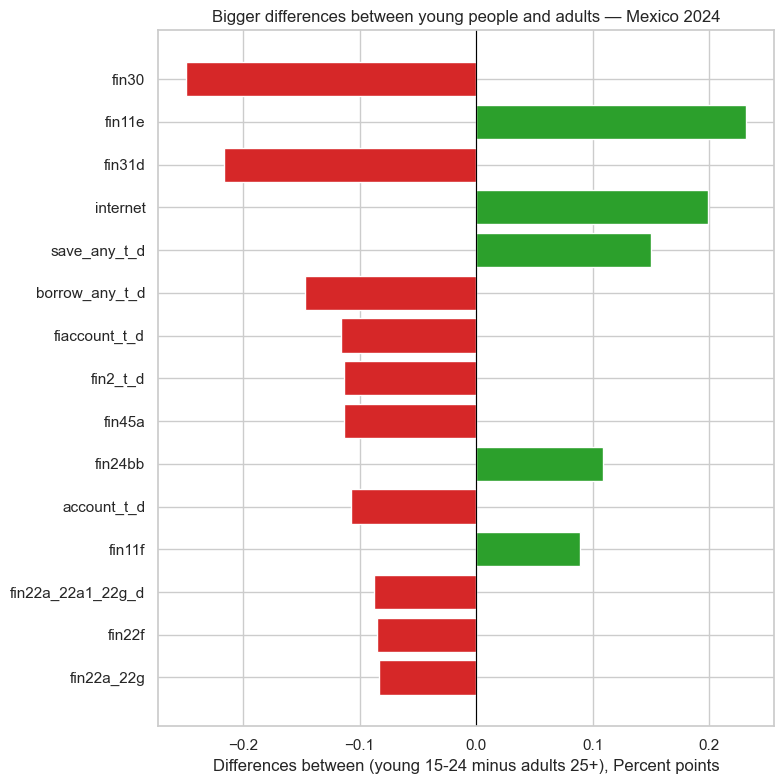

In [36]:
top_diffs = diffs_abs.head(15)  # top 15 differences in magnitude

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#2ca02c' if v > 0 else '#d62728' for v in top_diffs.values]
ax.barh(top_diffs.index, top_diffs.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Differences between (young 15-24 minus adults 25+), Percent points')
ax.set_title('Bigger differences between young people and adults — Mexico 2024')
ax.invert_yaxis()  # sort differences, the biggest at the begining
plt.tight_layout()
plt.show()

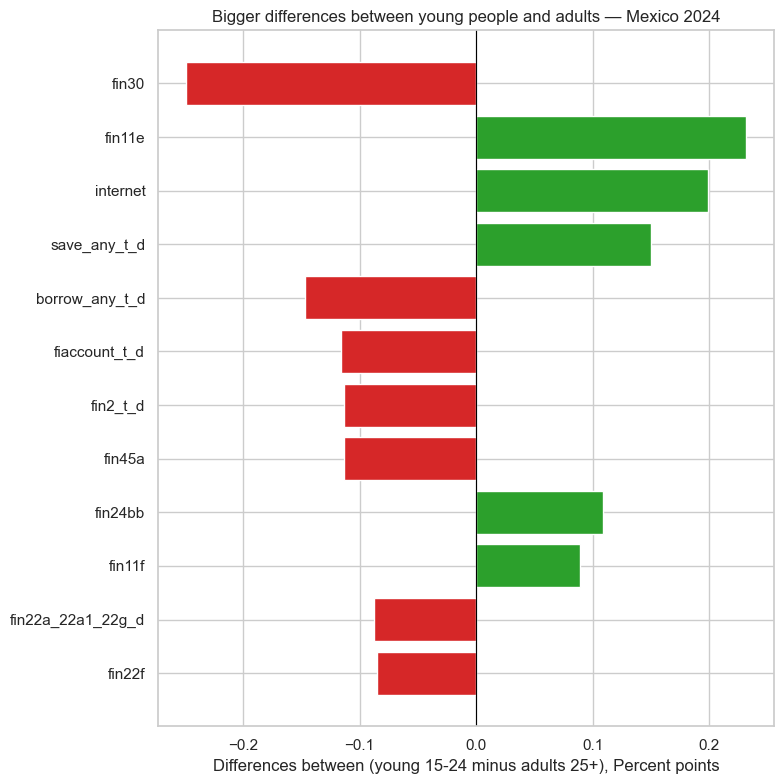

In [37]:
# Clean redundant variables

top_diffs_clean = ['fin30', 'fin11e', 'internet', 'save_any_t_d', 'borrow_any_t_d', 'fiaccount_t_d', 'fin2_t_d', 'fin45a', 'fin24bb', 'fin11f', 'fin22a_22a1_22g_d', 'fin22f']

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#2ca02c' if v > 0 else '#d62728' for v in top_diffs[top_diffs_clean].values]
ax.barh(top_diffs[top_diffs_clean].index, top_diffs[top_diffs_clean].values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Differences between (young 15-24 minus adults 25+), Percent points')
ax.set_title('Bigger differences between young people and adults — Mexico 2024')
ax.invert_yaxis()  # sort differences, the biggest at the begining
plt.tight_layout()
plt.savefig('comparison_2024_savings_mx_diff_age.png', dpi=150)
plt.show()

In [38]:
print(mx_age)

           countrynewwb codewb  year   pop_adult  \
group2                                             
age 25+          Mexico    MEX  2024  97411242.0   
ages 15-24       Mexico    MEX  2024  97411242.0   

                                                regionwb24_hi  \
group2                                                          
age 25+     Latin America & Caribbean (excluding high income)   
ages 15-24  Latin America & Caribbean (excluding high income)   

                incomegroupwb24    group  account_t_d  fiaccount_t_d  \
group2                                                                 
age 25+     Upper middle income  age_cat     0.554321       0.549750   
ages 15-24  Upper middle income  age_cat     0.446702       0.433799   

            mobileaccount_t_d  ...  con12m_s  con26lm_s  con12w_s  con2f_s  \
group2                         ...                                           
age 25+              0.104693  ...       NaN        NaN       NaN      NaN   
ages 15

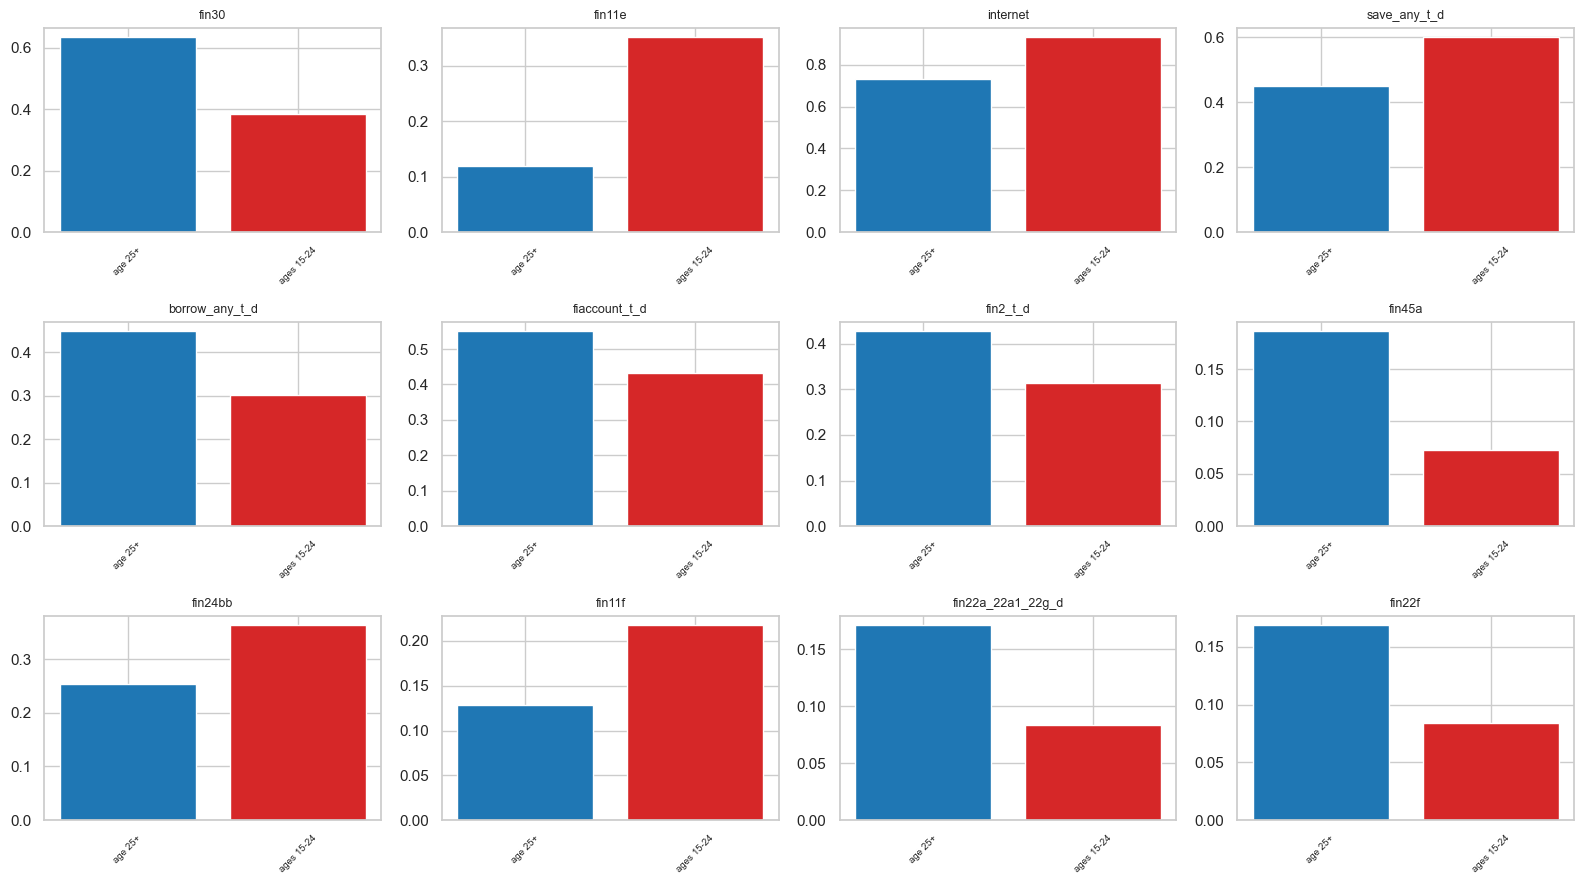

In [39]:
# Graph top correlated variables with savings by age

ages = ['age 25+', 'ages 15-24']
df_diff_age = mx_2024[mx_2024['group2'].isin(ages)].set_index('group2')

n_cols = 4
n_rows = int(np.ceil(len(top_diffs_clean) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()

for i, var in enumerate(top_diffs_clean):
    values = df_diff_age[var].reindex(ages)
    colors = ['#d62728' if p == 'ages 15-24' else '#1f77b4' for p in ages]  # Focus on
    axes[i].bar(ages, values, color=colors)
    axes[i].set_title(var, fontsize=9)
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('comparacion_var_ages.png', dpi=150)
plt.show()

The 15-to-24 age group (young people) saves the most. Men save more than women, and urban residents save more than rural residents.
The main differences between young people (the group that reported saving the most) and adults are: 
1) young people pay less for services; 
2) young people hold fewer bank accounts; 
3) young people use the Internet more; 
4) young people save more; 
5) young people apply for fewer loans; 
6) young people have fewer accounts; 
7) young people have fewer debit cards; 
8) young people worry less about retirement; 
9) more young people have an emergency fund; 
10) young people reported trusting banks less; 
11) young people have applied for fewer bank loans; and 
12) young people reported fewer food purchases on credit.

Hints:

- (6) Fewer accounts and (7) less debit cards suggest savings outside the banking system.
- (10) Trusting less in the banking system could explain why they (2) have less bank accounts.
- (5, 11, 12) Applying for fewer loans could suggest they spend less, therfore, (4) save more.

Research:

- (9) More young people with emergency fund could mean the same that savings, more research is needed.

Bias:

- (3) Young people using more internet, (1) paying less for services and (8) worring about retirment could be an age bias.


## Mexico along other LATAM countries

In [40]:
lam_countries = df_raw[df_raw['regionwb24_hi'] == 'Latin America & Caribbean (excluding high income)']['countrynewwb'].unique()
# print(lam_countries)

# Empty list for results
gaps = []
# Loop for each country
for country in lam_countries:
    # Where
    subsample = df_raw[(df_raw['countrynewwb'] == country) & (df_raw['year'] == 2024) & (df_raw['group2'].isin(['ages 15-24', 'age 25+']))]
    # Loop for each variable where both groups are reported
    if subsample['group2'].nunique() == 2: # Ensure that both(2) groups have reported results
        row = subsample.set_index('group2')[numeric_not_con] # Set index as 'ages 15-24' and 'age 25+'; show only financial variables
        gap = row.loc['ages 15-24'] - row.loc['age 25+'] # Compute variable gap between groups
        gap['countrynewwb'] = country
        gaps.append(gap) # Add results to empty list

df_gaps = pd.DataFrame(gaps).set_index('countrynewwb')
print(df_gaps.shape)

(16, 85)


In [41]:
# Select redundant variables related to savings
cols_save = ['save_any_t_d', 'fin8', 'fin17a', 'fin17a_17a1_d', 'fin17dm', 'fin24sav', 'fin24ba', 'fin24bb', 'fin24bc', 'fin24bd', 'fin6w', 'fin22b', 'fin29']

gap_corr = df_gaps.corr()['save_any_t_d'].drop(cols_save).sort_values(key=abs, ascending=False)
print(gap_corr.to_string())

fin6lm               0.709039
fin24c              -0.643413
fin24d1             -0.514737
fin31b              -0.484866
fin27a               0.476908
fh2                  0.457957
fin10               -0.447366
g20_made             0.430278
fin26b               0.419702
fin31a_31b          -0.405850
fin5m               -0.387195
borrow_any_t_d       0.375580
fin11f               0.375532
fin32_n33            0.327647
fin30               -0.322198
fin22d               0.301294
fin32_n33_acc        0.299449
fh1_fh2              0.287726
mobileaccount_t_d    0.282426
fin31a              -0.282220
fin24fam_SD_ND       0.278900
g20_any              0.264802
fin45a              -0.260070
fin25e2              0.252520
fin25e1             -0.234825
merchant_pay         0.210319
fin11c               0.208386
fin32_n33_34a        0.202538
fin24fam_VD         -0.196110
dig_acc              0.192109
fin11b               0.191364
internet            -0.189737
fin24aP              0.177660
fin22a_22g

In [ ]:
# fin6lm               0.709039 sent or withdrew money bank month
# fin24c              -0.643413 natural disaster
# fin24d1             -0.514737 natural disaster loss
# fin31b              -0.484866 utility paymente mobile phone
# fin27a               0.476908 made digital merchant payment
# fh2                  0.457957 received domestic remittances
# fin6w               -0.455724 sent or withdrew money bank weekly
# fin10               -0.447366 owns credit card
# fin22b               0.439620 borrowed friend
# g20_made             0.430278 made digital payment
# fin26b               0.419702 mobile to buy online
# fin31a_31b          -0.405850 made utility payment account
# fin5m               -0.387195 deposit money bank
# borrow_any_t_d       0.375580 borrowed
# fin11f               0.375532 No account lack trust bank
# fin29                0.338122 received domestic remittances account
# fin32_n33            0.327647 public sector wages
# fin30               -0.322198 made utility payment
# fin22d               0.301294 borrowed for health
# fin32_n33_acc        0.299449 private sector wages
# fh1_fh2              0.287726 sent received domestic remittances
# mobileaccount_t_d    0.282426 mobile account
# fin31a              -0.282220 made utility payment bank
# fin24fam_SD_ND       0.278900 emergency fund family
# g20_any              0.264802 made received digital payment
# fin45a              -0.260070 most worry money old age
# fin25e2              0.252520 mobile or card to pay in store
# fin25e1             -0.234825 mobile or card to pay food
# merchant_pay         0.210319 made digital merchant payment
# fin11c               0.208386 no account due to documentation
# fin32_n33_34a        0.202538 private sector wages
# fin24fam_VD         -0.196110 emergency fund family
# dig_acc              0.192109
# fin11b               0.191364 no account too expensive
# internet            -0.189737
# fin24aP              0.177660
# fin22a_22g          -0.174510
# fh2a                -0.171009
# fin24aND             0.169575
# fin28_29             0.168269
# fin2_t_d            -0.166625
# fin3                 0.161992
# fin45d               0.150726
# fin37_38             0.140865
# fin9a               -0.139947
# fin24aSD_ND          0.136319
# fin45c               0.132177
# fin28                0.123258
# fin11d               0.116827 no account insufficient funds
# account_t_d          0.115985
# fin31d              -0.110764
# fing2p              -0.110204
# fh1                  0.106474
# fin22a_22a1_22g_d   -0.100773
# fin32                0.088705
# fin6m               -0.084039
# fin24fam             0.078201
# fin25e2b            -0.076296
# fin26a              -0.069806
# fin25e4d             0.068261
# fin24aVD            -0.068109
# fin11a              -0.065402 no account bank is too far away
# fin11_2a            -0.061675
# fin11e               0.054600 no account someone else in family has one
# fin34a              -0.049695
# fin24sav_SD_ND       0.047348
# fin24work            0.041264
# fin4_d              -0.039953
# fin24aSD             0.039836
# fin9b                0.034627
# g20_received         0.031826
# fin22f              -0.028713
# fiaccount_t_d       -0.013762
# fin36b               0.012913
# fin32_acc           -0.005955

In [43]:
# Choose variables 

top_diff_country = ['fin6lm', 'fin24d1', 'fin31b', 'fin27a', 'fh2', 'fin6w', 'fin10', 'fin22b', 'g20_made', 'fin11f', 'fin32_n33', 'fin32_n33_acc']

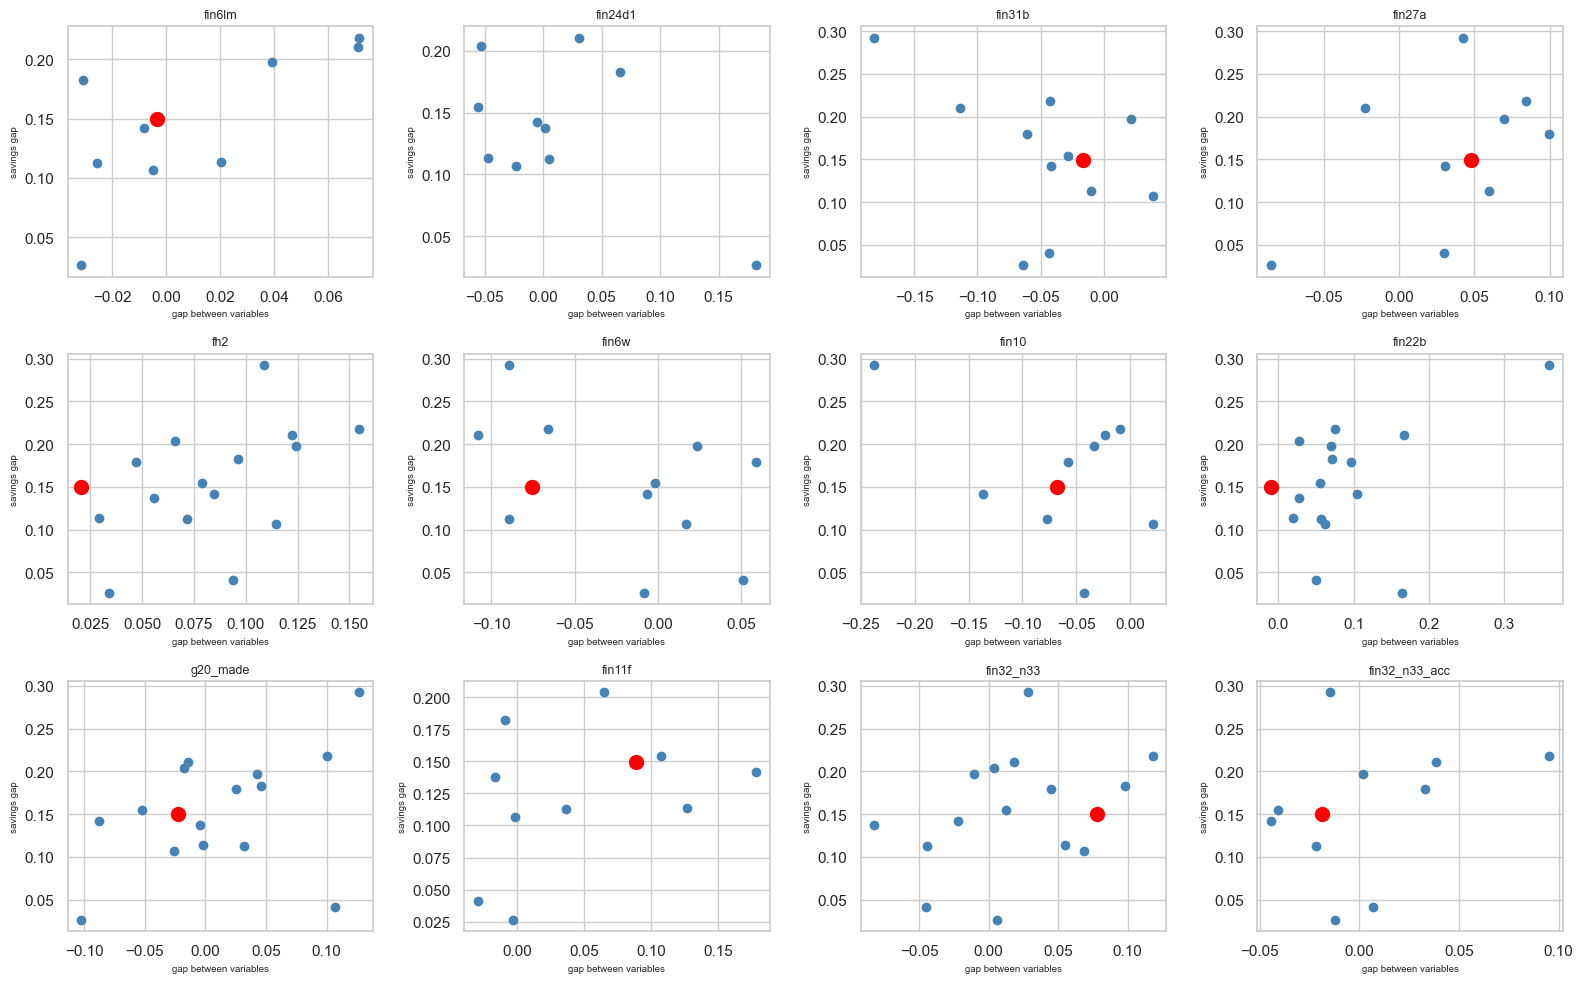

In [44]:
# Graph variables gaps

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(top_diff_country):
    axes[i].scatter(df_gaps[var], df_gaps['save_any_t_d'], color='steelblue')
    # Focus on Mexico
    if 'Mexico' in df_gaps.index:
        axes[i].scatter(df_gaps.loc['Mexico', var], df_gaps.loc['Mexico', 'save_any_t_d'], 
                         color='red', s=100, zorder=5, label='Mexico')
    axes[i].set_title(var, fontsize=9)
    axes[i].set_xlabel('gap between variables', fontsize=7)
    axes[i].set_ylabel('savings gap', fontsize=7)

plt.tight_layout()
plt.savefig('scatter_gaps.png', dpi=150)
plt.show()

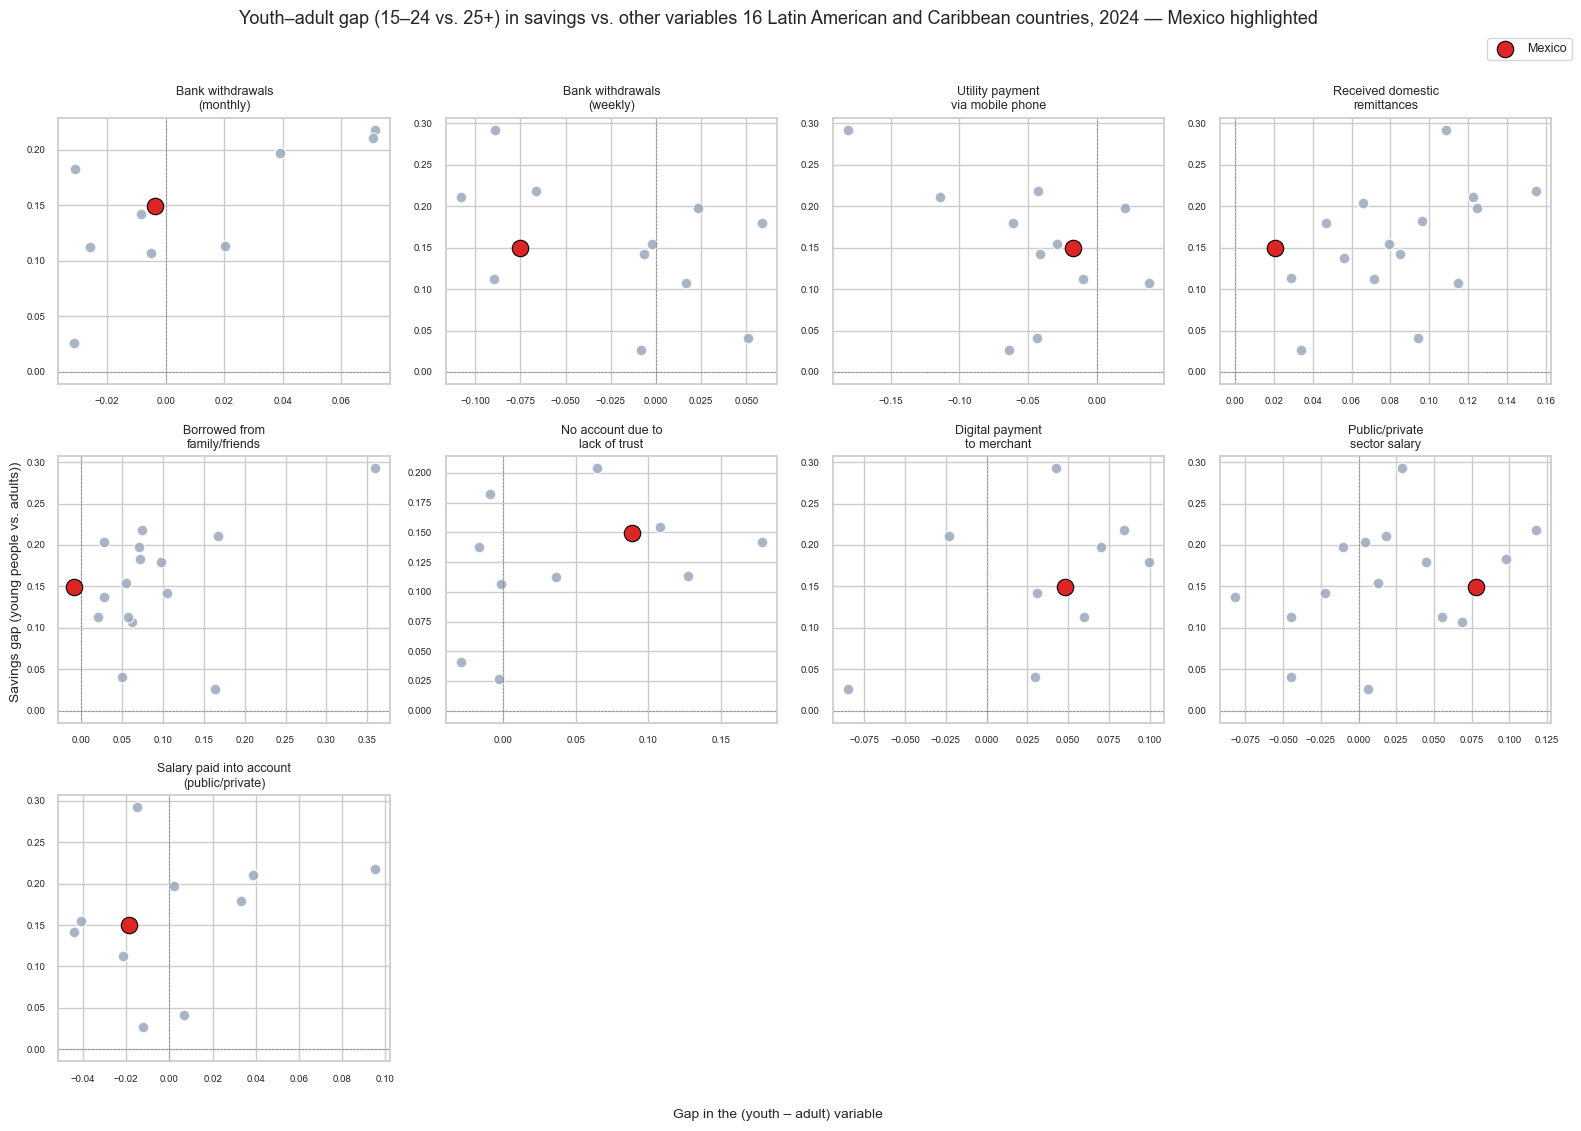

In [45]:
# Organiztion by topic
category = {
    'Bank account use': ['fin6lm', 'fin6w', 'fin31b'],
    'Informal support networks / credit': ['fh2', 'fin22b', 'fin11f'],
    'Digital payments': ['fin27a'],
    'Employment formality': ['fin32_n33', 'fin32_n33_acc'],
}

top_diff_country = [v for group in category.values() for v in group]

tags = {
    'fin6lm': 'Bank withdrawals\n(monthly)',
    'fin24c': 'Experienced\nnatural disaster',
    'fin24d1': 'Income loss\ndue to disaster',
    'fin31b': 'Utility payment\nvia mobile phone',
    'fin27a': 'Digital payment\nto merchant',
    'fh2': 'Received domestic\nremittances',
    'fin6w': 'Bank withdrawals\n(weekly)',
    'fin10': 'Has credit\ncard',
    'fin22b': 'Borrowed from\nfamily/friends',
    'fin11f': 'No account due to\nlack of trust',
    'fin32_n33': 'Public/private\nsector salary',
    'fin32_n33_acc': 'Salary paid into account\n(public/private)',
}

n_cols = 4
n_rows = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 11))
axes = axes.flatten()

for i, var in enumerate(top_diff_country):
    ax = axes[i]
    ax.scatter(df_gaps[var], df_gaps['save_any_t_d'], color='#94a3b8', s=60, alpha=0.8, edgecolor='white')
    
    if 'Mexico' in df_gaps.index:
        ax.scatter(df_gaps.loc['Mexico', var], df_gaps.loc['Mexico', 'save_any_t_d'],
                   color='#dc2626', s=140, zorder=5, edgecolor='black', linewidth=0.8, label='Mexico')
    
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_title(tags.get(var, var), fontsize=9)
    ax.tick_params(labelsize=7)


for j in range(len(top_diff_country), len(axes)):
    axes[j].axis('off')

fig.suptitle('Youth–adult gap (15–24 vs. 25+) in savings vs. other variables 16 Latin American and Caribbean countries, 2024 — Mexico highlighted',
             fontsize=13, y=1.02)
fig.supxlabel('Gap in the (youth – adult) variable', fontsize=10)
fig.supylabel('Savings gap (young people vs. adults))', fontsize=10)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.0, 1.0), fontsize=9)

plt.tight_layout()
plt.savefig('gaps_young_adults_latam.png', dpi=150, bbox_inches='tight')
plt.show()

## Insights

Mexico shows a positive gap regarding young people who save compared to adults. When comparing this gap against various variables, some show a stronger correlation with saving; these can be grouped according to bank account usage, informal credit networks, digital payments, and employment formality.

Regarding bank account usage, there is a negative gap—indicating that fewer young people make withdrawals or pay for services via bank accounts—with Mexico aligning with the regional trend.

As for informal credit networks, there is a positive gap indicating that more young people rely on family loans and domestic remittances; Mexico follows the regional trend here, whereas the region is divided regarding distrust of banking institutions.

Regarding digital payments to merchants, there is a positive gap indicating that more young people make digital purchases, with Mexico once again following the regional trend.

Regarding employment formality, young Mexicans show a positive gap in receiving private-sector wages, while there is a negative gap in the public sector—indicating that young people find more employment in the private sector than in the public sector; both variables reflect a regional division.

## Hypothesis


Hypothesis 1

Young people save more informally due to a lack of trust in financial institutions.

Data show a positive gap in youth savings and a negative gap in banking-related activities.
Furthermore, the data indicate a positive gap in youth savings and a positive gap regarding distrust of financial institutions; young people also rely more heavily on loans from friends and family.

Necessary evidence:

Data from financial institutions regarding complaints or dispute resolutions concerning accounts held by young people, compared with those of adults; additionally, data on financial inclusion.

Hypothesis 2

Young people save more because they have less access to credit.

Data show lower rates of credit-based purchases and fewer credit applications among young people compared to adults.
Given that credit is essentially a matter of bringing future money into the present—with a return charged on it—young people, having less access to future funds (credit), must accumulate resources before spending them; this would explain the higher savings rate.

Necessary evidence:

Data from financial institutions regarding credit applications and the reasons for their approval or denial.

## Recommendations


- Enable young people to have greater access to junior accounts at their financial institutions.
- Invest in building trust, placing special emphasis on young people, as they are the least trusting group.
- Implement mechanisms that allow young people to save while making digital purchases—an area where they are particularly active.